In [1]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time
import os
from queer.functions import get_rotation_matrix

In [2]:
# Input files
file_path = "./Ag_primitive/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=8.310342,poscar='POSCAR')
g_vec = model.g_vec

In [3]:
k_points = 200
custom_points = [
    [0, 0, 0],   # Gamma
    [1/2, 0, 1/2],     # X
    [1/2, 1/4, 3/4],   # W
    [0.375, 0.375, 3/4], # K
    [0, 0, 0],     # Gamma
    [1/2, 1/2, 1/2] # L
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['Γ', 'X', 'W', 'K', 'Γ', 'L']

Calculating band structure...


Plotting band structure...


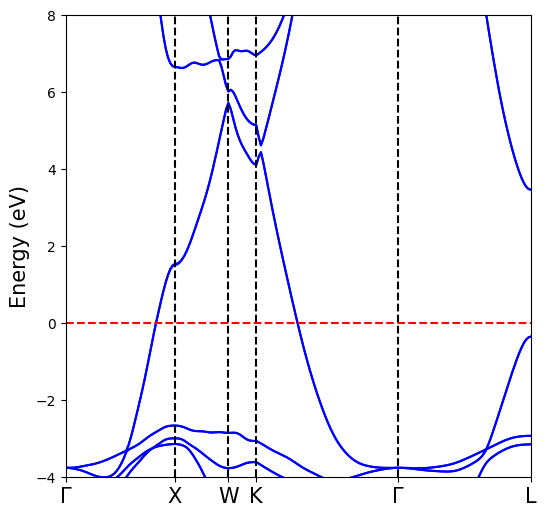

In [4]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,8])


In [5]:
k_points = 200
custom_points = [
    [1/2, 1/2, 1/2], # L
    [1/2, 1/4, 3/4],   # W
    [0.375, 0.375, 3/4], # K
    [1/2, 1/2, 1/2] # L    
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['L', 'W', 'K','L']

Calculating band structure...
Plotting band structure...


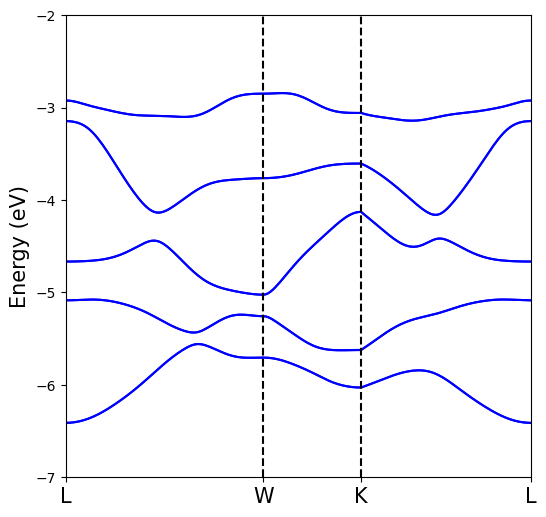

In [6]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-7,-2])


In [7]:
N = 300
factor = 4
kx,ky,kz = mesh_cartesian(N=[N,N,1],factor=factor).T-factor/2
K = np.array([kx,ky,kz])
K= (K.T + np.array([0,0,factor/2])).T

rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
rot_mesh = rot_mat@K
inv_mesh = angstrom2reciprocal(rot_mesh.T,g_vec=model.g_vec)


In [8]:
# Given:
# K.shape == (3, nk) with K[2, :] == 0
nk = K.shape[1]

# Choose the kz sampling (either by count or step)
n_kz = 10  # e.g., 67 slices → linspace(0, 1.32, 67)
# step = 0.02
# n_kz = int(np.floor(1.32/step)) + 1
kz_vals = np.linspace(0.0, 1.32, n_kz)  # (n_kz,)

Ks = np.repeat(K[np.newaxis, :, :], n_kz, axis=0)  # (n_kz, 3, nk)
Ks[:, 2, :] = kz_vals[:, None]                     # broadcast kz onto each slice


In [9]:
shift_array = [-6.2,-5.7,-5.2,-4.7]

Exception ignored in: <finalize object at 0x14b876ff7e20; dead>
Traceback (most recent call last):
  File "/projects/bansil/s.sevim/Dev/queer/.venv/lib/python3.12/weakref.py", line 590, in __call__
Exception ignored in: <finalize object at 0x1475921bc4c0; dead>
Traceback (most recent call last):
  File "/projects/bansil/s.sevim/Dev/queer/.venv/lib/python3.12/weakref.py", line 585, in __call__
Exception ignored in: <finalize object at 0x14e9c9b794e0; dead>
Traceback (most recent call last):
  File "/projects/bansil/s.sevim/Dev/queer/.venv/lib/python3.12/weakref.py", line 590, in __call__
Process LokyProcess-34:
Process LokyProcess-2:
Process LokyProcess-36:
Process LokyProcess-55:
        return info.func(*info.args, **(info.kwargs or {}))def __call__(self, _=None):

    return info.func(*info.args, **(info.kwargs or {}))

KeyboardInterrupt: 
           ^^^^^^^^^^^^^^^^^^^^^^^^^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^^
^^^^^^  File "/projects/bansil/s.sevim/Dev/queer/.venv/lib/python3.12/s

KeyboardInterrupt: 

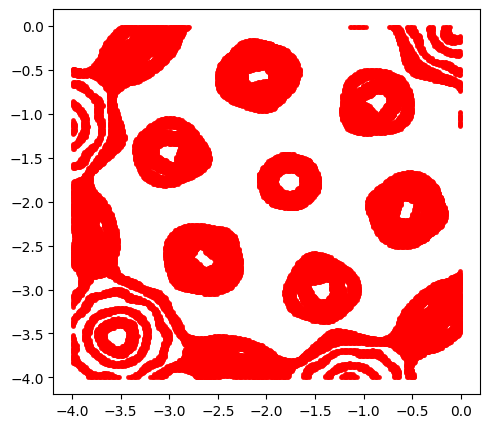

In [10]:
plt.figure(figsize=(5.5, 5))
energies = []
shift = -6.2
for z_slice in Ks:
    rot_mesh = rot_mat@z_slice
    inv_kmesh = angstrom2reciprocal(rot_mesh.T, g_vec)
    band = model.calculate_energy(inv_kmesh)
    energies.append(band)
    delta = 0.05  # eV
    nband, nk = band.shape
    near_any = np.any(np.abs(band-shift) <= delta, axis=0)  # (nk,)
    plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(f"k-points with any band |E| ≤ {delta} eV")
plt.tight_layout()
plt.axis("equal")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----- build kz-stacked K once -----
nk = K.shape[1]
n_kz = 20
kz_vals = np.linspace(0.0, 1.32, n_kz)

Ks = np.repeat(K[np.newaxis, :, :], n_kz, axis=0)  # (n_kz, 3, nk)
Ks[:, 2, :] = kz_vals[:, None]

# ----- PRECOMPUTE (ONCE) -----
bands_all = []
for idx, (kz, Kslice) in enumerate(zip(kz_vals, Ks), start=1):
    print(f"[{idx:02d}/{n_kz}] kz = {kz:.5f}")

    rot_mesh  = rot_mat @ Kslice                           # (3, nk)
    inv_kmesh = angstrom2reciprocal(rot_mesh.T, g_vec)     # (3, nk) depending on your function
    band      = np.asarray(model.calculate_energy(inv_kmesh))  # (nband, nk)

    # Optional quick shape check (uncomment if useful)
    # if band.ndim != 2 or band.shape[1] != nk:
    #     raise ValueError(f"Unexpected band shape at slice {idx}: {band.shape}")

    bands_all.append(band)

bands_all = np.stack(bands_all, axis=0)  # (n_kz, nband, nk)
print("Done. bands_all shape:", bands_all.shape)


[01/20] kz = 0.00000
[02/20] kz = 0.06947
[03/20] kz = 0.13895
[04/20] kz = 0.20842
[05/20] kz = 0.27789
[06/20] kz = 0.34737
[07/20] kz = 0.41684
[08/20] kz = 0.48632
[09/20] kz = 0.55579
[10/20] kz = 0.62526
[11/20] kz = 0.69474
[12/20] kz = 0.76421
[13/20] kz = 0.83368
[14/20] kz = 0.90316
[15/20] kz = 0.97263
[16/20] kz = 1.04211
[17/20] kz = 1.11158
[18/20] kz = 1.18105
[19/20] kz = 1.25053
[20/20] kz = 1.32000
Done. bands_all shape: (20, 18, 90000)


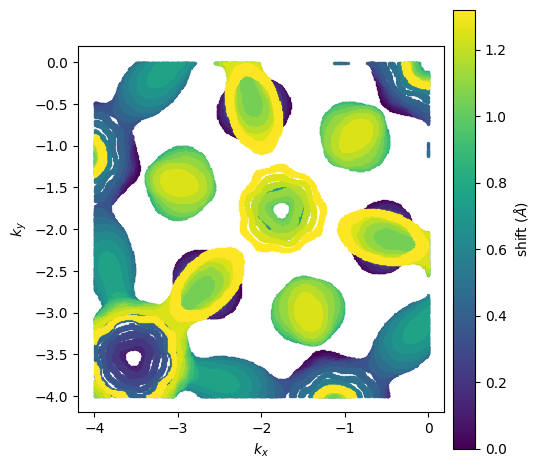

In [ ]:
delta = 0.05  # eV
shift=-6.2
fig, ax = plt.subplots(figsize=(5.5, 5))

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=kz_vals.min(), vmax=kz_vals.max())

for i, kz in enumerate(kz_vals):
    band = bands_all[i]  # (nband, nk)
    near_any = np.any(np.abs(band-shift) <= delta, axis=0)  # (nk,)

    ax.scatter(
        kx[near_any], ky[near_any],
        s=6, alpha=0.9,
        c=[cmap(norm(kz))],
        linewidths=0
    )

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_aspect("equal", adjustable="box")

# colorbar showing kz
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"shift $(\AA)$")

# tight layout + save high-quality transparent PNG
fig.tight_layout()
fig.savefig(
    "kxy_slices.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


In [ ]:
N = 300
factor = 4
binding_range = [3.2, 6.2]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = 15
binding_energy=0

In [ ]:
mesh_array =  np.array(arpes_mesh(photon_energy,fermi_energy,binding_energy,V0,N,factor,align=[[0,0,1],[1,1,1]]))

In [ ]:
mesh_array

array([[-0.43072552, -0.43072552,  3.02182909],
       [-0.4213846 , -0.40805126,  3.02628967],
       [-0.41232191, -0.38565524,  3.03047202],
       ...,
       [ 1.90065182,  1.87398516, -1.54214211],
       [ 1.88595381,  1.87262047, -1.56172047],
       [ 1.87097755,  1.87097755, -1.58157706]], shape=(90000, 3))

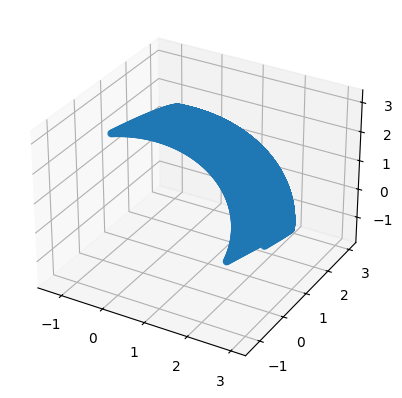

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(mesh_array.T[0],mesh_array.T[1],mesh_array.T[2])

plt.show()

In [ ]:
inv_mesh_array = angstrom2reciprocal(mesh_array, g_vec)
    

In [ ]:
band = model.calculate_energy(inv_mesh_array)

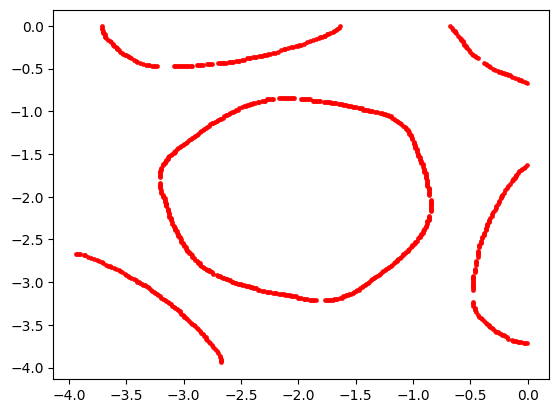

In [ ]:
delta = 0.05  # eV
nband, nk = band.shape
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')

In [ ]:
# Function to format time in a readable way
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f} seconds"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.2f} minutes"
    else:
        hours = seconds / 3600
        return f"{hours:.2f} hours"

Energy calculations took 4.29 minutes
Data processing took 0.56 seconds
Plotting took 8.56 seconds
Total execution time: 4.44 minutes


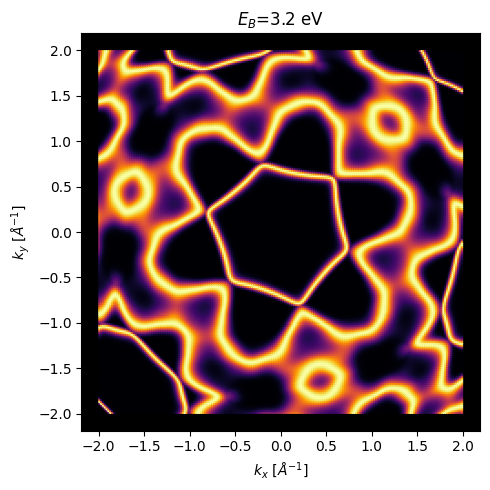

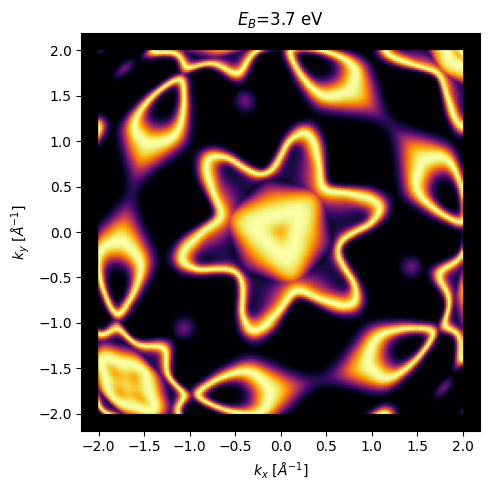

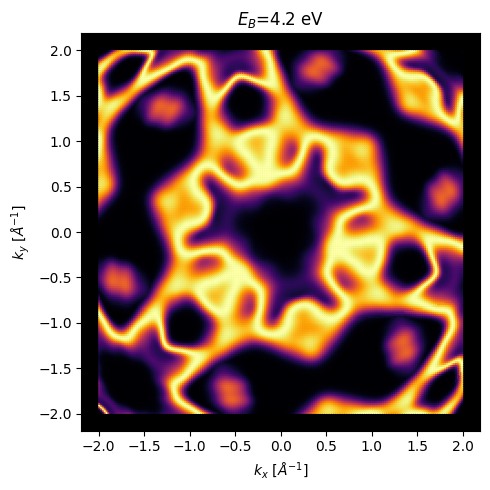

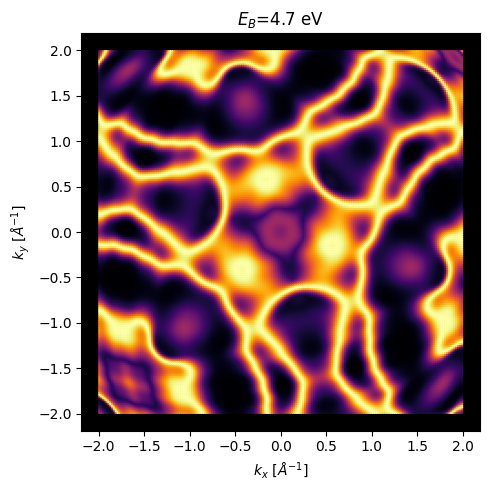

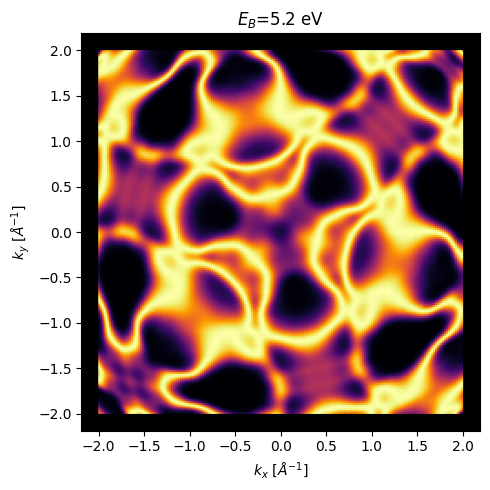

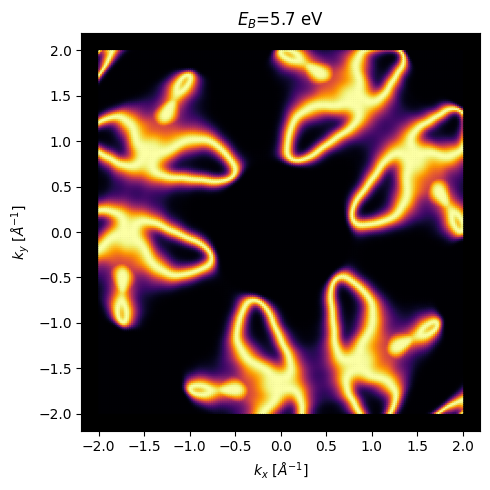

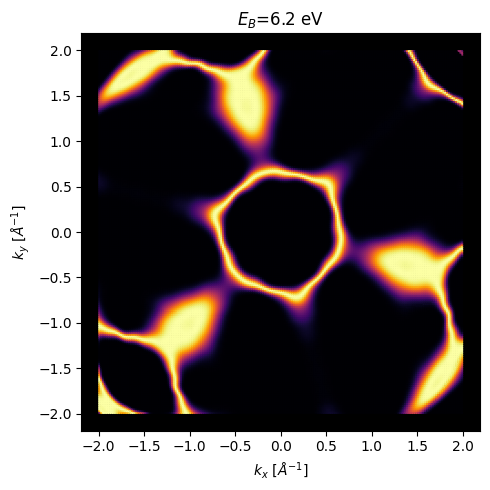

In [ ]:
N = 200
factor = 4
binding_range = [3.2, 6.7]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = [15]
align = [[0,0,1],[1,1,1]]
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
energy_shift=[0]
for shift in energy_shift:
    for v in V0:
        kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range, binding_step, v, N, factor,align)

        start_total = time.time()
        # Energy calculations
        start_energy = time.time()
        energy_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            inv_kmesh = angstrom2reciprocal(kmesh.T, g_vec)
            band = model.calculate_energy(inv_kmesh) 
            energy_dict[i] = band + shift
        end_energy = time.time()
        print(f"Energy calculations took {format_time(end_energy - start_energy)}")

        # Data processing: mesh tiling to intensity calculation
        start_data = time.time()
        mesh_tile_dict = {}
        band_tile_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            tile_mesh = []
            for k in range(energy_dict[i].shape[0]):
                tile_mesh.append(kmesh.T)
            mesh_tile = np.array(tile_mesh).reshape(-1, 3)
            mesh_tile_dict[i] = mesh_tile
            band_tile = energy_dict[i].flatten()
            band_tile_dict[i] = band_tile

        df_dict = {}
        for i, j in kmesh_dict.items():
            mesh_tile = mesh_tile_dict[i]
            band_tile = band_tile_dict[i]
            df = pd.DataFrame()
            df['kx'] = mesh_tile.T[0]
            df['ky'] = mesh_tile.T[1]
            df['kz'] = mesh_tile.T[2]
            df['e'] = band_tile
            df_dict[i] = df

        df_shift = {name: df.copy(deep=True) for name, df in df_dict.items()}
        # energy_shift = df_shift[0].query('e<=0').max().e

        # for i, j in df_shift.items():
        #     j.e -= energy_shift

        intensity_dict = {}
        for i, j in df_shift.items():
            j["I"] = np.exp(-((j.e + i)**2) / (2 * 0.1**2))
            group_max = j.loc[j.groupby(['kx', 'ky'])['I'].idxmax()]
            intensity_dict[i] = group_max
        end_data = time.time()
        print(f"Data processing took {format_time(end_data - start_data)}")
        start_plot = time.time()
        for i, j in intensity_dict.items():
            K = np.array([j.kx,j.ky,j.kz])
            inv_trans = rot_mat.T@K
            fig = plt.figure(figsize=(5, 5))
            plt.scatter(inv_trans[0], inv_trans[1], c=j.I, cmap='inferno', s=1)
            # plt.scatter(j.kx, j.ky, c=j.I, cmap='inferno', s=1)
            plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
            plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
            plt.title(fr"${{E_B}}$={np.around(i,2)} eV")
            # plt.title(fr"${{V_0}}$={v} eV")
            plt.gca().set_facecolor('black')
            # plt.xlim(-2, 2)
            # plt.ylim(-2, 2)
            plt.tight_layout()
            os.makedirs(f'Ag_primitive/figs/V0_{v}_shift_{shift}', exist_ok=True)    
            figure_path = f"Ag_primitive/figs/V0_{v}_shift_{shift}/{np.around(i,2)}.png"
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            # frame_files.append(figure_path)
            # plt.close(fig)  # Close figure to free memory instead of showing
        end_plot = time.time()
        print(f"Plotting took {format_time(end_plot - start_plot)}")

        # Total execution time
        end_total = time.time()
        print(f"Total execution time: {format_time(end_total - start_total)}")

In [ ]:
# --- add near the top (before the loops) ---
bands_mem = {}  # bands_mem[shift][V0][E_B] = ndarray shape (nk, nbands)

# optional: how tightly to select "around -E_B" (eV)
dE = 0.05  # adjust (e.g. 0.02, 0.1)
N = 200
factor = 4
binding_range = [3.2, 6.7]
binding_step = 0.5
photon_energies = [21.22]
fermi_energy = 0
V0 = [15]
align = [[0,0,1],[1,1,1]]
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
energy_shift=[-0.5,0.5]


# ------------------------------------------------
for hv in photon_energies:
    bands_mem.setdefault(hv, {})

    for shift in energy_shift:
        bands_mem[hv].setdefault(shift, {})

        for v in V0:
            bands_mem[hv][shift].setdefault(v, {})

            kmesh_dict = binding_k(hv, fermi_energy, binding_range, binding_step, v, N, factor, align)

            # -------- Energy calculations (keep as-is, but store) --------
            energy_dict = {}
            for be, j in kmesh_dict.items():
                kmesh = np.array(j)
                inv_kmesh = angstrom2reciprocal(kmesh.T, g_vec)
                band = model.calculate_energy(inv_kmesh)
                band = band + shift

                energy_dict[be] = band
                bands_mem[hv][shift][v][be] = band  # <-- store in memory by hv

            # -------- Build per-binding-energy dataframe (as you do) --------
            df_dict = {}
            for be, j in kmesh_dict.items():
                kmesh = np.array(j)
                tile_mesh = np.repeat(kmesh.T[None, ...], energy_dict[be].shape[0], axis=0)
                mesh_tile = tile_mesh.reshape(-1, 3)
                band_tile = energy_dict[be].reshape(-1)

                df_dict[be] = pd.DataFrame({
                    "kx": mesh_tile[:, 0],
                    "ky": mesh_tile[:, 1],
                    "kz": mesh_tile[:, 2],
                    "e":  band_tile,
                })

            # -------- "bands around -E_B" --------
            bands_slice_dict = {}
            for be, df in df_dict.items():
                dfc = df.copy()
                dfc["abs_err"] = np.abs(dfc["e"] + be)

                idx = dfc.groupby(["kx", "ky"])["abs_err"].idxmin()
                closest = dfc.loc[idx]
                closest = closest[closest["abs_err"] <= dE]
                bands_slice_dict[be] = closest

            # -------- Plot + save (per hv, per v, per shift, per be) --------
            outdir = f"Ag_primitive/figs/hv_{hv:.2f}/V0_{v}/shift_{shift}/bands"
            os.makedirs(outdir, exist_ok=True)

            for be, dff in bands_slice_dict.items():
                # skip empty slices (can happen when tolerance dE is tight)
                if len(dff) == 0:
                    continue

                K = np.array([dff.kx.to_numpy(), dff.ky.to_numpy(), dff.kz.to_numpy()])
                inv_trans = rot_mat.T @ K

                plt.figure(figsize=(5, 5))
                plt.scatter(inv_trans[0], inv_trans[1], s=1)
                plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
                plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
                plt.title(fr"$h\nu$={hv:.2f} eV, $E_B$={be:.2f} eV $V_0$={v:.2f} eV)")
                plt.tight_layout()

                figure_path = f"{outdir}/EB_{be:.2f}.png"
                plt.savefig(figure_path, dpi=300, bbox_inches="tight", transparent=True)
                plt.close()

In [ ]:
kmesh.shape

In [ ]:
df_shift

In [ ]:
bands = model.calculate_energy(path)
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()


In [ ]:
curved_path = arpes_path(path,g_vec,Ek=21.2,V0=15)
bands = model.calculate_energy(curved_path)

In [ ]:
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))


In [ ]:
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()

In [ ]:
v0_array = [15]
deltaE=np.linspace(0,-3,300)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(path,g_vec,Ek=21.2-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


In [ ]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=sym, labels=labels, fontsize=15)
    plt.xlim(sym[0], sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    plt.savefig(f'figs/arpes_path/k_400/V0_{j}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()
